# RuBR-AT for RAPID: train, evaluate, and fine-tune

Notebook for RAPID collaborators who already have (or will build) NPZ detection shards and want to:

1. **Train** a Real/Bogus model from scratch on labeled NPZ data
2. **Evaluate** with a validation-selected threshold (never tune on test)
3. **Fine-tune / resume** from a previous checkpoint when a new labeled campaign arrives

It includes a **short runnable demo** on a tiny stratified subset so cells finish in minutes on CPU/GPU, plus **copy-paste CLI** for full production runs.

Companion notebook: `notebooks/demo_inference.ipynb` (score an existing checkpoint and inspect cutouts).


## How this maps to flight / new campaigns

| Stage | What you do |
| --- | --- |
| Shadow | Score with the pinned sim (or previous) checkpoint; do not gate alerts yet |
| Review | Build labeled NPZ for a new campaign (train/val/test splits; hold out a frozen test) |
| Calibrate | Retune threshold / score calibration on reviewed val labels |
| Update weights | Fine-tune (`--resume`) or retrain; pin new `best.keras` + scaler + threshold |
| Promote | Only after the frozen eval set meets the alert FPR/precision target |

**Rule:** raw new detections are evaluation/calibration first. Reviewed labels may enter the next train/val; keep a held-out test that never trains.


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

# Set False to use GPU for the short demo train.
FORCE_CPU = True
if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""

print("ROOT =", ROOT)
print("python =", sys.executable)


ROOT = /data/akuloor/RuBR-AT
python = /data/akuloor/miniconda3/envs/roman-surf/bin/python


## Config

- `RUN_DEMO_TRAIN=True` builds tiny shards and runs a 2-epoch toy train + fine-tune (for learning the path).
- Production numbers need the full shards and ~40 epochs (CLI section below) — do not treat demo metrics as science results.


In [2]:
RUN_DEMO_TRAIN = True
DEMO_SEED = 42
# Tiny subsets so the notebook is runnable in a meeting / on a laptop.
N_TRAIN = 512
N_VAL = 256
N_TEST = 256
DEMO_EPOCHS = 2
FINETUNE_EPOCHS = 2
FINETUNE_LR = 1e-5  # lower than configs/rb_model.yaml (1e-4)

DEMO_DIR = ROOT / "notebooks" / "_demo_cache" / "train_demo"
DEMO_DIR.mkdir(parents=True, exist_ok=True)

# Source campaign used to build the toy shards (HLTDS only for speed).
# For joint HLTDS+GBTDS production training, see the CLI section at the bottom.
SRC_TRAIN = ROOT / "artifacts/datasets/hltds_ou24_equal/train_0.npz"
SRC_VAL = ROOT / "artifacts/datasets/hltds_ou24_equal/val_0.npz"
SRC_TEST = ROOT / "artifacts/datasets/hltds_ou24_equal/test_0.npz"
BASE_CKPT = ROOT / "outputs/ablations/baseline/seed42/best.keras"  # for fine-tune demo
CONFIG = ROOT / "configs/rb_model.yaml"

for path in (SRC_TRAIN, SRC_VAL, SRC_TEST, CONFIG):
    if not path.is_file():
        raise FileNotFoundError(path)
print("demo out =", DEMO_DIR)
print("base ckpt exists =", BASE_CKPT.is_file())


demo out = /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo
base ckpt exists = True


## 0. Helper: stratified subset writer

NPZ contract (required keys): `X`, `feats`, `y`, `survey_id`, `filter_id`, `metadata`.  
Features in the NPZ stay **raw**; the JSON scaler is applied by the loader.


In [3]:
def stratified_take(y: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    n = min(n, len(y))
    idx0 = np.flatnonzero(y == 0)
    idx1 = np.flatnonzero(y == 1)
    n1 = int(round(n * (len(idx1) / max(len(y), 1))))
    n1 = min(max(n1, 1 if len(idx1) else 0), len(idx1), n - (1 if len(idx0) else 0))
    n0 = min(n - n1, len(idx0))
    pick = np.concatenate(
        [
            rng.choice(idx0, size=n0, replace=False) if n0 else np.array([], dtype=int),
            rng.choice(idx1, size=n1, replace=False) if n1 else np.array([], dtype=int),
        ]
    )
    rng.shuffle(pick)
    return pick


def write_subset(src: Path, dst: Path, n: int, seed: int) -> dict:
    raw = np.load(src, allow_pickle=True)
    idx = stratified_take(raw["y"], n, np.random.default_rng(seed))
    payload = {
        "X": raw["X"][idx],
        "feats": raw["feats"][idx],
        "y": raw["y"][idx],
        "survey_id": raw["survey_id"][idx],
        "filter_id": raw["filter_id"][idx],
        "metadata": raw["metadata"][idx],
    }
    dst.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(dst, **payload)
    return {"path": str(dst), "n": int(len(idx)), "pos_rate": float(np.mean(payload["y"]))}


if RUN_DEMO_TRAIN:
    info = {
        "train": write_subset(SRC_TRAIN, DEMO_DIR / "train_0.npz", N_TRAIN, DEMO_SEED),
        "val": write_subset(SRC_VAL, DEMO_DIR / "val_0.npz", N_VAL, DEMO_SEED + 1),
        "test": write_subset(SRC_TEST, DEMO_DIR / "test_0.npz", N_TEST, DEMO_SEED + 2),
    }
    print(json.dumps(info, indent=2))
else:
    print("RUN_DEMO_TRAIN=False — skip subset build; use production CLI cells only.")


{
  "train": {
    "path": "/data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/train_0.npz",
    "n": 512,
    "pos_rate": 0.298828125
  },
  "val": {
    "path": "/data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/val_0.npz",
    "n": 256,
    "pos_rate": 0.3125
  },
  "test": {
    "path": "/data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/test_0.npz",
    "n": 256,
    "pos_rate": 0.29296875
  }
}


## 1. Validate shards

Always validate before fitting a scaler or training.


In [4]:
from rubrat.validation import validate_dataset, write_report

if RUN_DEMO_TRAIN:
    report = validate_dataset(
        [
            DEMO_DIR / "train_0.npz",
            DEMO_DIR / "val_0.npz",
            DEMO_DIR / "test_0.npz",
        ]
    )
    out = DEMO_DIR / "validation.json"
    write_report(report, out)
    print("wrote", out)
    print("valid =", report.get("valid"))
    print("n_shards =", report.get("n_shards"), "n_rows =", report.get("n_rows"))
    if report.get("errors"):
        print("errors:", report["errors"])


wrote /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/validation.json
valid = True
n_shards = 3 n_rows = 1024


## 2. Fit the feature scaler (**train only**)

Never fit the scaler on val/test. Same rule for flight: fit on the labeled train pool for that model version.


In [5]:
from classification.data_utils import save_feature_scaler

if RUN_DEMO_TRAIN:
    SCALER = DEMO_DIR / "scaler_demo.json"
    payload = save_feature_scaler([DEMO_DIR / "train_0.npz"], SCALER)
    print(f"wrote {SCALER} from {payload['n_rows']} train rows")
    print("feature_names:", payload.get("feature_names"))


wrote /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/scaler_demo.json from 512 train rows
feature_names: ['arcsinh_snr', 'cfit', 'is_fit_clean', 'log1p_chi2', 'log1p_pos_err', 'log_npixfit', 'roundness1', 'roundness2', 'sharpness']


## 3. Train from scratch (short demo)

This mirrors `rubrat train supervised`. Checkpoint selection monitors **validation macro-F1**.


In [6]:
from tensorflow import keras

from classification import gpu_config  # noqa: F401 — sets memory growth
from classification.losses import focal_bce
from classification.model_factory import build_rb_model, load_config
from classification.training import (
    ValidationReportCallback,
    WarmupCosineDecay,
    make_finite_training_dataset,
    prefer_gpu_memory_growth,
    save_history,
    set_reproducible,
    steps_for,
    write_json,
)


def compile_rb_model(model: keras.Model, cfg: dict, *, lr_override: float | None = None) -> keras.Model:
    weight_decay = float(cfg.get("weight_decay", 1e-4))
    clipnorm = float(cfg.get("clipnorm", 1.0))
    schedule = cfg["learning_rate_schedule"]
    if lr_override is not None:
        # Constant LR for short fine-tunes / demos (skip long cosine schedule).
        opt_lr = float(lr_override)
    else:
        opt_lr = schedule
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=opt_lr,
            weight_decay=weight_decay,
            clipnorm=clipnorm,
        ),
        loss={"rb": focal_bce(gamma=2.0)},
        metrics={
            "rb": [
                keras.metrics.BinaryAccuracy(name="accuracy"),
                keras.metrics.AUC(name="roc_auc"),
                keras.metrics.AUC(curve="PR", name="pr_auc"),
            ]
        },
    )
    return model


def train_run(
    *,
    train_npz,
    val_npz,
    scaler,
    output: Path,
    config_path: Path,
    seed: int,
    epochs: int,
    batch_size: int = 64,
    resume: Path | None = None,
    lr_override: float | None = None,
    early_stopping_patience: int = 5,
):
    set_reproducible(seed)
    prefer_gpu_memory_growth()
    cfg = load_config(config_path)
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)

    steps_per_epoch = steps_for(train_npz, "y", batch_size)
    validation_steps = steps_for(val_npz, "y", batch_size)
    total_steps = max(1, epochs * steps_per_epoch)
    warmup_epochs = int(cfg.get("warmup_epochs", 3)) if lr_override is None else 0
    warmup_steps = min(total_steps - 1, max(0, warmup_epochs * steps_per_epoch)) if total_steps > 1 else 0
    lr = float(lr_override if lr_override is not None else cfg.get("lr", 1e-4))
    min_lr_ratio = float(cfg.get("min_lr_ratio", 0.05))
    schedule = WarmupCosineDecay(
        initial_learning_rate=lr,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_learning_rate=lr * min_lr_ratio,
    )
    cfg["learning_rate_schedule"] = schedule

    if resume is not None:
        model = keras.models.load_model(resume, compile=False)
        model = compile_rb_model(model, cfg, lr_override=lr_override)
    else:
        model = build_rb_model(cfg)
        model = compile_rb_model(model, cfg, lr_override=lr_override)

    train_ds = make_finite_training_dataset(
        train_npz, scaler, label_key="y", output_name="rb",
        batch_size=batch_size, shuffle=True, seed=seed,
    )
    val_ds = make_finite_training_dataset(
        val_npz, scaler, label_key="y", output_name="rb",
        batch_size=batch_size, shuffle=False, seed=seed,
    )

    write_json(
        output / "run_metadata.json",
        {
            "task": "rb",
            "mode": "finetune" if resume else "from_scratch",
            "resume": None if resume is None else str(resume),
            "feats_scaler": str(scaler),
            "train": [str(train_npz)],
            "val": [str(val_npz)],
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "lr_override": lr_override,
            "seed": seed,
        },
    )

    callbacks = [
        ValidationReportCallback(
            [val_npz], scaler, output_name="rb", label_key="y", num_classes=2, output_dir=output
        ),
        keras.callbacks.ModelCheckpoint(
            output / "best.keras", monitor="val_rb_macro_f1", mode="max", save_best_only=True
        ),
        keras.callbacks.CSVLogger(output / "keras_history.csv"),
        keras.callbacks.EarlyStopping(
            monitor="val_rb_macro_f1",
            mode="max",
            patience=early_stopping_patience,
            restore_best_weights=True,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
    )
    model.save(output / "final.keras")
    save_history(history, output)
    return output, history


if RUN_DEMO_TRAIN:
    SCRATCH_OUT = DEMO_DIR / "from_scratch"
    scratch_dir, scratch_hist = train_run(
        train_npz=DEMO_DIR / "train_0.npz",
        val_npz=DEMO_DIR / "val_0.npz",
        scaler=DEMO_DIR / "scaler_demo.json",
        output=SCRATCH_OUT,
        config_path=CONFIG,
        seed=DEMO_SEED,
        epochs=DEMO_EPOCHS,
        batch_size=64,
        resume=None,
        lr_override=1e-4,
        early_stopping_patience=5,
    )
    print("wrote", scratch_dir / "best.keras")


2026-09-25 02:20:09.331291: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 02:20:09.352624: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-25 02:20:10.048725: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790328010.748342 3841017 gpu_device.cc:2020] C

Epoch 1/2


2026-09-25 02:20:20.674755: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f3ae4014a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-25 02:20:20.674784: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-09-25 02:20:20.968903: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-25 02:20:21.185134: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90/Assert/AssertGuard/Assert
2026-09-25 02:20:21.187625: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90_1/Assert/AssertGuard/Assert
2026-09-25 02:20:21.188351: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_e

2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6094 - loss: 0.2583 - pr_auc: 0.2808 - roc_auc: 0.5291 

I0000 00:00:1790328049.431348 3841330 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6510 - loss: 0.2313 - pr_auc: 0.3786 - roc_auc: 0.5918

2026-09-25 02:20:51.257090: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90/Assert/AssertGuard/Assert
2026-09-25 02:20:51.259519: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90_1/Assert/AssertGuard/Assert
2026-09-25 02:20:51.260634: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90_2/Assert/AssertGuard/Assert
2026-09-25 02:20:51.262752: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90_3/Assert/AssertGuard/Assert
2026-09-25 02:20:51.263341: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90_4/Assert/AssertGuard/Assert
2026-09-25 02:20:51.265456: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator rb_model_1/rotinv_encoder_1/rot90_5/Assert/AssertG

8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6758 - loss: 0.2054 - pr_auc: 0.4507 - roc_auc: 0.6474 - val_accuracy: 0.7695 - val_loss: 0.1334 - val_pr_auc: 0.6486 - val_roc_auc: 0.8015 - val_rb_macro_f1: 0.6974
Epoch 2/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.7930 - loss: 0.1255 - pr_auc: 0.6719 - roc_auc: 0.8188 - val_accuracy: 0.8047 - val_loss: 0.1194 - val_pr_auc: 0.7696 - val_roc_auc: 0.8439 - val_rb_macro_f1: 0.7448
wrote /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/from_scratch/best.keras


## 4. Plot training curves


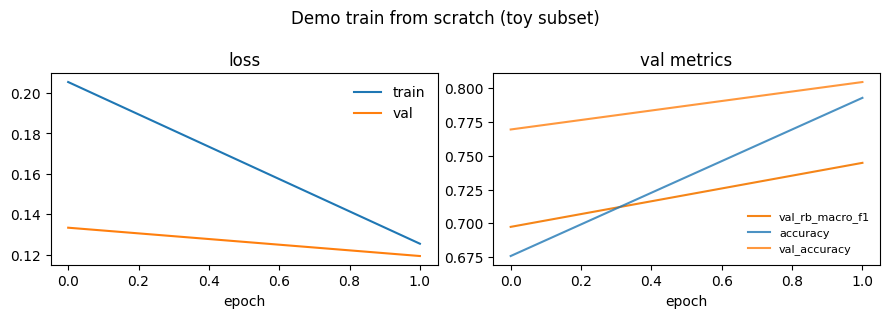

In [7]:
def plot_history(run_dir: Path, title: str):
    hist_path = run_dir / "history.json"
    csv_path = run_dir / "keras_history.csv"
    if hist_path.is_file():
        hist = json.loads(hist_path.read_text())
    elif csv_path.is_file():
        import csv
        with csv_path.open() as f:
            rows = list(csv.DictReader(f))
        hist = {k: [float(r[k]) for r in rows] for k in rows[0] if k != "epoch"}
    else:
        raise FileNotFoundError(f"No history in {run_dir}")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    # loss
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend(frameon=False)

    # macro-F1 if present, else accuracy
    f1_key = next((k for k in ("val_rb_macro_f1", "rb_macro_f1") if k in hist), None)
    if f1_key:
        axes[1].plot(hist[f1_key], label=f1_key, color="#F58518")
    for key in ("rb_accuracy", "val_rb_accuracy", "accuracy", "val_accuracy"):
        if key in hist:
            axes[1].plot(hist[key], label=key, alpha=0.8)
    axes[1].set_title("val metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend(frameon=False, fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


if RUN_DEMO_TRAIN:
    plot_history(SCRATCH_OUT, "Demo train from scratch (toy subset)")


## 5. Evaluate (validation threshold → test)

Same path as `rubrat evaluate-research`. Threshold is chosen on **val** only.


In [8]:
from rubrat.evaluate import evaluate

if RUN_DEMO_TRAIN:
    eval_out = DEMO_DIR / "eval_from_scratch"
    result = evaluate(
        SCRATCH_OUT / "best.keras",
        [DEMO_DIR / "val_0.npz"],
        [DEMO_DIR / "test_0.npz"],
        DEMO_DIR / "scaler_demo.json",
        eval_out,
        survey="hltds",
        mag_limit_ab=None,  # toy subset: skip mag policy
        batch_size=64,
    )
    thr = result["validation_threshold"]
    print("validation threshold:", thr)
    print("test macro-F1 (full):", result["full"]["metrics"]["macro_f1"])
    print("metrics ->", eval_out / "metrics.json")
    print("predictions ->", eval_out / "predictions.csv")


validation threshold: {'threshold': 0.39744186046511626, 'macro_f1': 0.7704923796297923, 'macro_precision': 0.7679852357406505, 'macro_recall': 0.7732954545454545, 'grid_low': 0.01, 'grid_high': 0.99, 'grid_size': 990}
test macro-F1 (full): 0.7528427376099549
metrics -> /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/eval_from_scratch/metrics.json
predictions -> /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/eval_from_scratch/predictions.csv


## 6. Fine-tune from a previous checkpoint (`--resume`)

Operational pattern when a **new labeled campaign** arrives:

1. Keep a frozen eval / test set from earlier reviews (or a dedicated flight holdout).
2. Build train/val NPZ from the new + older reviewed labels (or new-only, depending on policy).
3. Prefer **refitting or extending the scaler on the new train pool** if feature stats shifted; otherwise reuse the paired scaler and document that choice.
4. Resume weights with a **lower LR**, fewer epochs, same early-stopping on val macro-F1.
5. Pin the new `best.keras`, scaler, threshold, and RAPID commit together.

Below: fine-tune the published seed-42 baseline on the toy train subset (stands in for “new labels”).


Epoch 1/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 861ms/step - accuracy: 0.8633 - loss: 0.1284 - pr_auc: 0.8765 - roc_auc: 0.9191 - val_accuracy: 0.9062 - val_loss: 0.0607 - val_pr_auc: 0.9372 - val_roc_auc: 0.9578 - val_rb_macro_f1: 0.8860
Epoch 2/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.8828 - loss: 0.1069 - pr_auc: 0.8695 - roc_auc: 0.9259 - val_accuracy: 0.8984 - val_loss: 0.0604 - val_pr_auc: 0.9354 - val_roc_auc: 0.9575 - val_rb_macro_f1: 0.8774
resumed from /data/akuloor/RuBR-AT/outputs/ablations/baseline/seed42/best.keras
wrote /data/akuloor/RuBR-AT/notebooks/_demo_cache/train_demo/finetune/best.keras


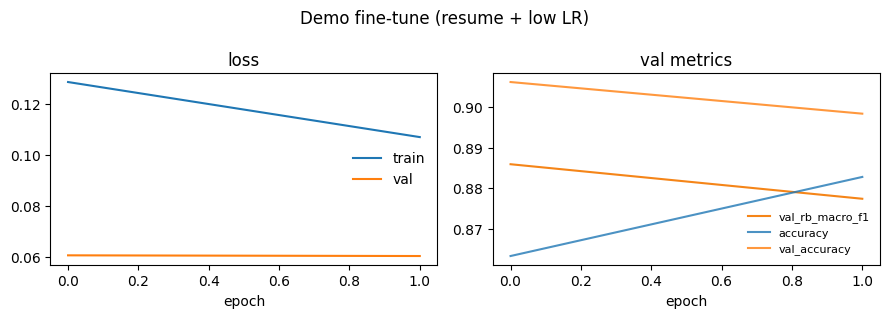

finetune val threshold: {'threshold': 0.5123862487360971, 'macro_f1': 0.8893545053086536, 'macro_precision': 0.9194925493354813, 'macro_recall': 0.8698863636363636, 'grid_low': 0.01, 'grid_high': 0.99, 'grid_size': 990}
finetune test macro-F1: 0.884310836034974


In [9]:
if RUN_DEMO_TRAIN:
    if not BASE_CKPT.is_file():
        print("BASE_CKPT missing — fine-tuning the from-scratch demo weights instead.")
        resume_ck = SCRATCH_OUT / "best.keras"
    else:
        resume_ck = BASE_CKPT

    FT_OUT = DEMO_DIR / "finetune"
    ft_dir, ft_hist = train_run(
        train_npz=DEMO_DIR / "train_0.npz",
        val_npz=DEMO_DIR / "val_0.npz",
        scaler=DEMO_DIR / "scaler_demo.json",
        output=FT_OUT,
        config_path=CONFIG,
        seed=DEMO_SEED,
        epochs=FINETUNE_EPOCHS,
        batch_size=64,
        resume=resume_ck,
        lr_override=FINETUNE_LR,
        early_stopping_patience=5,
    )
    print("resumed from", resume_ck)
    print("wrote", ft_dir / "best.keras")
    plot_history(FT_OUT, "Demo fine-tune (resume + low LR)")

    ft_eval = DEMO_DIR / "eval_finetune"
    ft_result = evaluate(
        FT_OUT / "best.keras",
        [DEMO_DIR / "val_0.npz"],
        [DEMO_DIR / "test_0.npz"],
        DEMO_DIR / "scaler_demo.json",
        ft_eval,
        survey="hltds",
        mag_limit_ab=None,
        batch_size=64,
    )
    print("finetune val threshold:", ft_result["validation_threshold"])
    print("finetune test macro-F1:", ft_result["full"]["metrics"]["macro_f1"])


## 7. What got written (artifact checklist)

Pin these together for any RAPID deployment / shadow promotion:


In [10]:
if RUN_DEMO_TRAIN:
    for run in (SCRATCH_OUT, FT_OUT):
        print("\n==", run.name, "==")
        for name in (
            "best.keras",
            "final.keras",
            "run_metadata.json",
            "history.json",
            "keras_history.csv",
            "best_validation_report.json",
        ):
            p = run / name
            print(("OK " if p.is_file() else "  "), p.relative_to(ROOT) if p.exists() else name)
    print("\nscaler:", (DEMO_DIR / "scaler_demo.json").relative_to(ROOT))



== from_scratch ==
OK  notebooks/_demo_cache/train_demo/from_scratch/best.keras
OK  notebooks/_demo_cache/train_demo/from_scratch/final.keras
OK  notebooks/_demo_cache/train_demo/from_scratch/run_metadata.json
OK  notebooks/_demo_cache/train_demo/from_scratch/history.json
OK  notebooks/_demo_cache/train_demo/from_scratch/keras_history.csv
OK  notebooks/_demo_cache/train_demo/from_scratch/best_validation_report.json

== finetune ==
OK  notebooks/_demo_cache/train_demo/finetune/best.keras
OK  notebooks/_demo_cache/train_demo/finetune/final.keras
OK  notebooks/_demo_cache/train_demo/finetune/run_metadata.json
OK  notebooks/_demo_cache/train_demo/finetune/history.json
OK  notebooks/_demo_cache/train_demo/finetune/keras_history.csv
OK  notebooks/_demo_cache/train_demo/finetune/best_validation_report.json

scaler: notebooks/_demo_cache/train_demo/scaler_demo.json


## 8. Production CLI (full data — copy/paste)

Use these on a GPU box for real campaigns. Paths assume the transferred paper layout; replace with your flight NPZ dirs later.

### Train from scratch (single survey)

```bash
export PYTHONPATH=src
export DATA=artifacts/datasets/hltds_ou24_equal
export OUT=outputs/rapiddemo/hltds_seed42

rubrat validate dataset "$DATA"/train_*.npz "$DATA"/val_*.npz "$DATA"/test_*.npz

rubrat dataset scaler \
  --npz "$DATA"/train_*.npz \
  --output artifacts/scalers/hltds_only.json

rubrat train supervised \
  --train "$DATA"/train_*.npz \
  --val "$DATA"/val_*.npz \
  --config configs/rb_model.yaml \
  --feats-scaler artifacts/scalers/hltds_only.json \
  --output "$OUT" \
  --seed 42

rubrat evaluate-research \
  --checkpoint "$OUT"/best.keras \
  --val "$DATA"/val_*.npz \
  --test "$DATA"/test_*.npz \
  --feats-scaler artifacts/scalers/hltds_only.json \
  --survey hltds \
  --mag-limit-ab 26.0 \
  --output-dir "$OUT"/eval_hltds
```

### Joint HLTDS + GBTDS (paper-style)

```bash
export PYTHONPATH=src
H=artifacts/datasets/hltds_ou24_equal
G=artifacts/datasets/gbtds_transient_only
OUT=outputs/rapiddemo/joint_seed42

rubrat dataset scaler \
  --npz "$H"/train_*.npz "$G"/train_*.npz \
  --output artifacts/scalers/canonical_9_refit.json

rubrat train supervised \
  --train "$H"/train_*.npz "$G"/train_*.npz \
  --val "$H"/val_*.npz "$G"/val_*.npz \
  --config configs/rb_model.yaml \
  --feats-scaler artifacts/scalers/canonical_9_refit.json \
  --output "$OUT" \
  --seed 42
```

### Fine-tune / resume on a new labeled campaign

```bash
# NEW_TRAIN / NEW_VAL = reviewed flight (or mixed) NPZ shards
# Keep OLD_TEST frozen for promotion checks.
export PYTHONPATH=src
export CKPT=outputs/ablations/baseline/seed42/best.keras
export OUT=outputs/rapiddemo/finetune_campaign1

rubrat dataset scaler \
  --npz /path/to/new_campaign/train_*.npz \
  --output artifacts/scalers/campaign1.json

rubrat train supervised \
  --train /path/to/new_campaign/train_*.npz \
  --val /path/to/new_campaign/val_*.npz \
  --config configs/rb_model.yaml \
  --feats-scaler artifacts/scalers/campaign1.json \
  --resume "$CKPT" \
  --epochs 10 \
  --output "$OUT" \
  --seed 42

# Optional: lower LR by editing configs/rb_model.yaml (lr: 1.0e-5) for that run,
# or add a campaign-specific yaml copied from configs/rb_model.yaml.
```

Score-only after promotion:

```bash
rubrat infer \
  --checkpoint "$OUT"/best.keras \
  --npz /path/to/new_campaign/test_*.npz \
  --feats-scaler artifacts/scalers/campaign1.json \
  --threshold-json "$OUT"/../eval/metrics.json \
  --output "$OUT"/predictions.csv
```


## 9. Ops notes for RAPID

1. **Version everything together:** `best.keras` SHA, scaler JSON, validation threshold, RAPID commit/image digest, NPZ split manifest.
2. **Threshold ≠ training objective alone:** choose the operating cut for the alert FPR/precision budget on reviewed val; macro-F1 is the training/selection metric in this repo.
3. **Retrain triggers (like coadd refresh):** enough new reviewed labels; drift on a frozen eval set; pipeline change (subtraction / extractor / references). Threshold/calibration updates can be more frequent than weight updates.
4. **Do not** fit scaler or pick threshold on the test / promotion set.
5. For early flight with sparse trusted positives, see `rubrat train pu` (positive-unlabeled) — separate from this supervised notebook.
6. Inference API for live RAPID catalogs: `docs/rapid-pipeline-integration.md` and `rubrat.rapid.RAPIDRealBogusClassifier`.


### Related docs

- [README](../README.md) — NPZ train/eval/infer commands  
- [docs/data.md](../docs/data.md) — cutouts, features, builders  
- [docs/rapid-pipeline-integration.md](../docs/rapid-pipeline-integration.md) — scoring into RAPID  
- [notebooks/demo_inference.ipynb](demo_inference.ipynb) — score + cutout gallery  
